In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 경고(W) 메시지만 숨김

In [2]:
import os 
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
import tensorflow as tf

# GPU 메모리 동적 할당 설정
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU 메모리 동적 할당 활성화 완료")
    except RuntimeError as e:
        print(e)

GPU 메모리 동적 할당 활성화 완료


In [3]:
tf.config.set_visible_devices([], 'GPU')

In [23]:
import pandas as pd

# KOTE 데이터셋 로드
train_df = pd.read_csv("KOTE/train.tsv", sep='\t')
test_df = pd.read_csv("KOTE/test.tsv", sep='\t')
val_df = pd.read_csv("KOTE/val.tsv", sep='\t')

# 데이터 확인
print(f"Train 데이터 크기: {train_df.shape}")
print(f"Test 데이터 크기: {test_df.shape}")
print(f"Validation 데이터 크기: {val_df.shape}")

# 데이터 샘플 출력
train_df.head()

Train 데이터 크기: (39999, 3)
Test 데이터 크기: (4999, 3)
Validation 데이터 크기: (4999, 3)


,39087,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,"2,13,15,16,29,39"
0,30893,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...","0,5,7,10,19,22,29,35,36,38"
1,45278,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...","1,2,7"
2,16398,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"9,15,20,23,26,28,29"
3,13653,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ,"1,2,8,9,11,13,15,16,28,29,32,40,42"
4,13748,어릴 때 했던 건데 아직도 볼 때마다 뒤통수 얼얼함 ㅋㅋㅋㅋ,"2,15,23,24,25,28,33"


In [28]:
import pandas as pd

# 올바른 컬럼명 지정 후 데이터 로드
train_df = pd.read_csv("KOTE/train.tsv", sep='\t', names=['id', 'comments', 'labels'], header=None)
test_df = pd.read_csv("KOTE/test.tsv", sep='\t', names=['id', 'comments', 'labels'], header=None)
val_df = pd.read_csv("KOTE/val.tsv", sep='\t', names=['id', 'comments', 'labels'], header=None)

# 데이터 확인
print(train_df.head())
print("📌 데이터 컬럼 목록:", train_df.columns)

      id                                           comments  \
0  39087              내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.   
1  30893  정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...   
2  45278  새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...   
3  16398       미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ   
4  13653                        네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ   

                               labels  
0                    2,13,15,16,29,39  
1          0,5,7,10,19,22,29,35,36,38  
2                               1,2,7  
3                 9,15,20,23,26,28,29  
4  1,2,8,9,11,13,15,16,28,29,32,40,42  
📌 데이터 컬럼 목록: Index(['id', 'comments', 'labels'], dtype='object')


In [29]:
import re

# 텍스트 정제 함수 (숫자 유지)
def clean_text(text):
    text = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9\s]", "", text)  # 한글, 숫자, 공백 제외한 문자 제거
    text = re.sub(r"\s+", " ", text).strip()  # 연속된 공백 제거
    return text

# 데이터 정제 적용
train_df['clean_text'] = train_df['comments'].apply(clean_text)
test_df['clean_text'] = test_df['comments'].apply(clean_text)
val_df['clean_text'] = val_df['comments'].apply(clean_text)

# 결과 확인
train_df[['comments', 'clean_text']].head(10)

,comments,clean_text
0,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,내가 톰행크스를 좋아하긴 했나보다 초기 영화 빼고는 다 봤네
1,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...",정말 상상을 초월하는 무개념 진상들 상대하다 우울증 공항장애 걸리는 공무원 많아요 ...
2,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...",새로운 세상과 조우한 자의 어린아이 같은 반응 어쩌면 회복된 것은 눈이 아닌 순수함...
3,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ
4,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ
5,어릴 때 했던 건데 아직도 볼 때마다 뒤통수 얼얼함 ㅋㅋㅋㅋ,어릴 때 했던 건데 아직도 볼 때마다 뒤통수 얼얼함 ㅋㅋㅋㅋ
6,물갈이약 구매했어요...미미네에서 수조2개랑 여러가지 용품사면서 3~4번 주문했었는...,물갈이약 구매했어요미미네에서 수조2개랑 여러가지 용품사면서 34번 주문했었는데 그 ...
7,"십일조는 겨우60인데? 나머지 다 어디감? 혹시 엄마아빠 그랜져따로타고, 외식자주하...",십일조는 겨우60인데 나머지 다 어디감 혹시 엄마아빠 그랜져따로타고 외식자주하는거아...
8,90년 줘야 하는거 아닌가? 쓰레기같은 것들.,90년 줘야 하는거 아닌가 쓰레기같은 것들
9,아주 부착성도 좋고 효과 100점 입니다,아주 부착성도 좋고 효과 100점 입니다


In [30]:
# ✅ 텍스트 데이터셋 로드
train_texts = train_df['clean_text'].tolist()
test_texts = test_df['clean_text'].tolist()
val_texts = val_df['clean_text'].tolist()

In [31]:
# 감정 라벨 개수 확인
print(train_df['labels'].value_counts())

labels
0,6,10,22,23,33                       125
0,6,10,12,22,23,33                    108
24                                     83
2,28,40,42                             65
0,10,22,37                             55
                                     ... 
0,3,10,12,20,21,22,23,24,27,31,35       1
0,5,10,19,20,22,25,27,31,36,38          1
0,2,3,8,20,22,23,24,28,29,32,33,39      1
1,11,14,15,16,27,29,38,39,41            1
2,9,10,15,18,23,33,35,39                1
Name: count, Length: 29332, dtype: int64


In [32]:
import pandas as pd

# 감정을 7개 그룹으로 정리하는 매핑 (KOTE의 44개 감정을 7개 감정 그룹으로 변환)
emotion_mapping = {
    '기쁨': [42, 40, 28],  # 기쁨, 행복, 즐거움/신남
    '슬픔': [5, 19, 25, 36],  # 슬픔, 절망, 패배/자기혐오, 서러움
    '놀람': [39, 34, 15, 2],  # 놀람, 경악, 신기함/관심, 감동/감탄
    '분노': [6, 22, 0],  # 화남/분노, 짜증, 불평/불만
    '공포': [18, 41],  # 공포/무서움, 불안/걱정
    '혐오': [31, 21],  # 증오/혐오, 역겨움/징그러움
    '중립': [24, 14, 43]  # 없음, 편안/쾌적, 안심/신뢰
}

# FER2013 기준 감정 라벨로 변환
fer2013_label_mapping = {
    '기쁨': 3,  # Happy
    '슬픔': 5,  # Sad
    '놀람': 6,  # Surprise
    '분노': 0,  # Angry
    '공포': 2,  # Fear
    '혐오': 1,  # Disgust
    '중립': 4   # Neutral
}

# 감정 그룹을 FER2013 기준으로 매핑하는 함수
def map_to_fer2013(label_str):
    if pd.isna(label_str) or label_str == '':
        return 6  # NaN 값은 중립(6)으로 처리

    label_list = list(map(int, label_str.split(',')))  # 숫자 리스트 변환
    for num in label_list:
        for key, values in emotion_mapping.items():  # KOTE 감정 그룹 확인
            if num in values:
                return fer2013_label_mapping[key]  # FER2013 감정으로 변환
    return 6  # 변환되지 않는 경우, 중립(6)으로 처리

# 감정 라벨 변환 적용 (NaN 값 처리 추가)
train_df['fer2013_emotion_grouped'] = train_df['labels'].fillna('').apply(map_to_fer2013)
test_df['fer2013_emotion_grouped'] = test_df['labels'].fillna('').apply(map_to_fer2013)
val_df['fer2013_emotion_grouped'] = val_df['labels'].fillna('').apply(map_to_fer2013)

# 변환된 감정 개수 확인
print(train_df['fer2013_emotion_grouped'].value_counts())

fer2013_emotion_grouped
0    18408
6    13984
4     3049
5     2300
3     1343
2      689
1      227
Name: count, dtype: int64


In [33]:
# ✅ 감정 라벨 (FER2013 매핑된 라벨)
train_labels = train_df['fer2013_emotion_grouped'].values
test_labels = test_df['fer2013_emotion_grouped'].values
val_labels = val_df['fer2013_emotion_grouped'].values

# 변환된 라벨 확인
print("라벨 변환 결과:", train_labels[:5])

라벨 변환 결과: [6 0 6 6 6]


In [34]:
# KoNLPy 라이브러리 설치
!pip install konlpy

from konlpy.tag import Okt

# Okt 토크나이저 인스턴스 생성
okt = Okt()

# 예제 문장 토큰화
text = "안녕하세요. 챗봇을 만들기 위한 텍스트 데이터 셋을 준비 중입니다."
tokens = okt.morphs(text)
print("형태소 단위 토큰:", tokens)



Defaulting to user installation because normal site-packages is not writeable
형태소 단위 토큰: ['안녕하세요', '.', '챗봇', '을', '만들기', '위', '한', '텍스트', '데이터', '셋', '을', '준비', '중', '입니다', '.']


In [35]:
from konlpy.tag import Okt

# Okt 토크나이저 인스턴스 생성
okt = Okt()

# 토큰화 함수
def tokenize(text):
    return okt.morphs(text)

# 토큰화 적용
train_df['tokenized'] = train_df['clean_text'].apply(tokenize)
test_df['tokenized'] = test_df['clean_text'].apply(tokenize)
val_df['tokenized'] = val_df['clean_text'].apply(tokenize)

# 결과 확인
print(train_df[['clean_text', 'tokenized']].head())

                                          clean_text  \
0                  내가 톰행크스를 좋아하긴 했나보다 초기 영화 빼고는 다 봤네   
1  정말 상상을 초월하는 무개념 진상들 상대하다 우울증 공항장애 걸리는 공무원 많아요 ...   
2  새로운 세상과 조우한 자의 어린아이 같은 반응 어쩌면 회복된 것은 눈이 아닌 순수함...   
3       미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ   
4                        네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ   

                                           tokenized  
0  [내, 가, 톰, 행크스, 를, 좋아하긴, 했나보다, 초기, 영화, 빼고는, 다, 봤네]  
1  [정말, 상상, 을, 초월, 하는, 무, 개념, 진상, 들, 상대, 하다, 우울증,...  
2  [새로운, 세상, 과, 조우, 한, 자의, 어린아이, 같은, 반응, 어쩌면, 회복,...  
3  [미역, 은, 원생생물계, 산호초, 는, 동물, ㅇㅇ, 아, 미역, 이, 바다, 의...  
4          [네, 맞습니다, 플스, 는, 역시, 30, 프레임, 이, 어울리죠, ㅎ]  


In [36]:
# 불용어 리스트
# "의", "가", "이", "은", "들", "는", "좀", "잘", "걍", "과",
#   "도", "를", "으로", "자", "에", "와", "한", "하다", "에서",
#    "까지", "부터", "마다", "보다", "더", "만", "요", "그리고",
#    "그러나", "하지만", "또한", "때문에", "그래서", "무엇", "어디",
#    "왜", "어떻게", "그래도", "그런데", "그러면", "하면", "이다",
#    "이런", "저런", "뿐", "만큼", "정도"
stopwords = [
    "의", "가", "이", "은", "들", "는", "걍", "과",
    "를", "으로", "자", "에", "와", "한", "하다", "에서",
    "요", "무엇", "어디", "하면", "이다"
]

# 불용어 제거 함수
def remove_stopwords(tokens):
    return [token for token in tokens if token not in stopwords]

# 불용어 제거 적용
train_df['tokenized'] = train_df['tokenized'].apply(remove_stopwords)
test_df['tokenized'] = test_df['tokenized'].apply(remove_stopwords)
val_df['tokenized'] = val_df['tokenized'].apply(remove_stopwords)

# 결과 확인
print(train_df[['clean_text', 'tokenized']].head())

                                          clean_text  \
0                  내가 톰행크스를 좋아하긴 했나보다 초기 영화 빼고는 다 봤네   
1  정말 상상을 초월하는 무개념 진상들 상대하다 우울증 공항장애 걸리는 공무원 많아요 ...   
2  새로운 세상과 조우한 자의 어린아이 같은 반응 어쩌면 회복된 것은 눈이 아닌 순수함...   
3       미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ   
4                        네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ   

                                           tokenized  
0        [내, 톰, 행크스, 좋아하긴, 했나보다, 초기, 영화, 빼고는, 다, 봤네]  
1  [정말, 상상, 을, 초월, 하는, 무, 개념, 진상, 상대, 우울증, 공항, 장애...  
2  [새로운, 세상, 조우, 자의, 어린아이, 같은, 반응, 어쩌면, 회복, 된, 것,...  
3  [미역, 원생생물계, 산호초, 동물, ㅇㅇ, 아, 미역, 바다, 새, ㄱㅇㄱㅋㅋㅋㅋ...  
4                [네, 맞습니다, 플스, 역시, 30, 프레임, 어울리죠, ㅎ]  


In [43]:
# PyTorch 데이터셋 변환 코드 시작
import torch
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB_SIZE = 50000

# 단어 사전 생성
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# 단어를 숫자로 변환
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)

# ✅ 텍스트 토큰화 및 패딩
MAX_SEQUENCE_LENGTH = max(len(seq) for seq in train_sequences)

# 최대 문장 길이 설정 (패딩)
train_padded = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
val_padded = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# NumPy 배열을 PyTorch 텐서로 변환 (정수 시퀀스는 long 타입으로)
train_text_tensor = torch.tensor(train_padded, dtype=torch.long)
train_label_tensor = torch.tensor(train_labels, dtype=torch.long)

test_text_tensor = torch.tensor(test_padded, dtype=torch.long)
test_label_tensor = torch.tensor(test_labels, dtype=torch.long)

val_text_tensor = torch.tensor(val_padded, dtype=torch.long)
val_label_tensor = torch.tensor(val_labels, dtype=torch.long)

# TensorDataset 생성: (텍스트, 레이블)
train_dataset = TensorDataset(train_text_tensor, train_label_tensor)
test_dataset = TensorDataset(test_text_tensor, test_label_tensor)
val_dataset = TensorDataset(val_text_tensor, val_label_tensor)

# DataLoader 생성
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train dataset size:", train_text_tensor.shape)
print("✅ PyTorch 텍스트 데이터셋 준비 완료!")

Train dataset size: torch.Size([40000, 98])
✅ PyTorch 텍스트 데이터셋 준비 완료!


In [44]:
import numpy as np

# 넘파이 배열 변환 
X_train, y_train = np.array(train_padded), np.array(train_labels)
X_val, y_val = np.array(val_padded), np.array(val_labels)
X_test, y_test = np.array(test_padded), np.array(test_labels)

print("훈련 데이터 크기:", X_train.shape, y_train.shape) 
print("검증 데이터 크기:", X_val.shape, y_val.shape)
print("테스트 데이터 크기:", X_test.shape, y_test.shape)

훈련 데이터 크기: (40000, 98) (40000,)
검증 데이터 크기: (5000, 98) (5000,)
테스트 데이터 크기: (5000, 98) (5000,)


In [ ]:
태양이형 수정 후

In [45]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight

# ─── 하이퍼파라미터 정의 ──────────────────────────────────────────
MAX_VOCAB_SIZE = 50000       # 토크나이저에서 지정한 num_words 값과 동일하게
EMBEDDING_DIM  = 300         # Keras 코드에서 쓰던 임베딩 차원


# ─── 1. 재현 가능한 결과를 위한 시드 고정 ─────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ─── 2. Attention 모듈 정의 ───────────────────────────────────────────────────────────────
class AttentionLayer(nn.Module):
    def __init__(self, feature_dim, dropout_rate=0.1):
        super().__init__()
        self.W = nn.Linear(feature_dim, feature_dim)
        self.V = nn.Linear(feature_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x, mask=None):
        # x: (batch, seq_len, feature_dim)
        score = self.V(torch.tanh(self.W(x)))  # (batch, seq_len, 1)
        if mask is not None:
            # mask: (batch, seq_len) -> (batch, seq_len, 1)
            score = score.masked_fill(mask.unsqueeze(-1)==0, -1e9)
        alpha = F.softmax(score, dim=1)         # (batch, seq_len, 1)
        alpha = self.dropout(alpha)
        context = (alpha * x).sum(dim=1)        # (batch, feature_dim)
        return context

# ─── 3. 모델 정의 ─────────────────────────────────────────────────────────────────────
class EmotionModel(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim=300,
                 num_filters=64,
                 kernel_size=3,
                 lstm_units=128,
                 dropout_rate=0.3,
                 num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Conv1D expects (batch, channels, seq_len)
        self.conv = nn.Conv1d(in_channels=embedding_dim,
                              out_channels=num_filters,
                              kernel_size=kernel_size,
                              padding=kernel_size//2)
        self.bn   = nn.BatchNorm1d(num_filters)
        
        self.bilstm = nn.LSTM(input_size=num_filters,
                              hidden_size=lstm_units,
                              batch_first=True,
                              bidirectional=True)
        
        self.attn = AttentionLayer(feature_dim=2*lstm_units,
                                   dropout_rate=dropout_rate)
        
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1     = nn.Linear(2*lstm_units, 64)
        self.fc2     = nn.Linear(64, num_classes)
    
    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)                          # (batch, seq_len, emb_dim)
        conv_in = emb.permute(0,2,1)                     # (batch, emb_dim, seq_len)
        conv_out = F.relu(self.bn(self.conv(conv_in)))  # (batch, num_filters, seq_len)
        seq = conv_out.permute(0,2,1)                   # (batch, seq_len, num_filters)
        
        lstm_out, _ = self.bilstm(seq)                  # (batch, seq_len, 2*lstm_units)
        attn_out    = self.attn(lstm_out)               # (batch, 2*lstm_units)
        
        x = self.dropout(attn_out)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)                              # (batch, num_classes)

# ─── 4. 학습/평가 함수 정의 ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    total_loss, total_correct, total_count = 0, 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(texts)
        loss = criterion(logits, labels)
        loss.backward()
        
        # ← 여기서 gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        
        optimizer.step()
        
        total_loss   += loss.item() * texts.size(0)
        preds         = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_count   += texts.size(0)
    return total_loss/total_count, total_correct/total_count


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_count = 0, 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            logits = model(texts)
            loss = criterion(logits, labels)
            
            total_loss += loss.item() * texts.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_count   += texts.size(0)
    return total_loss/total_count, total_correct/total_count

# ─── 5. 하이퍼파라미터 및 준비 ────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 주어진 DataLoader: train_loader, val_loader, test_loader
# class weight 계산 (train_loader.dataset.tensors[1] 이 레이블 텐서라고 가정)
all_train_labels = train_loader.dataset.tensors[1].cpu().numpy()
classes = np.unique(all_train_labels)
weights = compute_class_weight('balanced', classes=classes, y=all_train_labels)
class_weights = torch.tensor(weights, dtype=torch.float, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

best_params = {
    'num_filters': 64,
    'kernel_size': 3,
    'lstm_units': 128,
    'dropout_rate': 0.3,
    'learning_rate': 3e-4,
    'epochs': 50,
}
n_ensemble = 7
early_stop_patience = 4

# ─── 6. Ensemble 학습 루프 ──────────────────────────────────────────────────────────────
ensemble_models = []
val_accuracies   = []

for i in range(n_ensemble):
    print(f"\n=== Training model {i+1}/{n_ensemble} (seed={42+i}) ===")
    set_seed(42 + i)
    
    model = EmotionModel(
        vocab_size=MAX_VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        num_filters=best_params['num_filters'],
        kernel_size=best_params['kernel_size'],
        lstm_units=best_params['lstm_units'],
        dropout_rate=best_params['dropout_rate'],
        num_classes=7
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['learning_rate'])
    # train_one_epoch 호출 시 max_grad_norm 전달
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, max_grad_norm=1.0
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
        verbose=True
    )    
    
    best_val_loss = float('inf')
    no_improve    = 0
    
    for epoch in range(1, best_params['epochs']+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = eval_one_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch:02d} ▶ train_loss={train_loss:.4f}, train_acc={train_acc:.4f} │ "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
        
        # EarlyStopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve    = 0
            # 개선 시 체크포인트 저장
            torch.save(model.state_dict(), f"checkpoint_model_{i}.pt")
        else:
            no_improve += 1
            if no_improve >= early_stop_patience:
                print(f"--> Early stopping at epoch {epoch}")
                break
    
    # 체크포인트 로드 후 평가
    model.load_state_dict(torch.load(f"checkpoint_model_{i}.pt", map_location=device))
    _, val_acc = eval_one_epoch(model, val_loader, criterion, device)
    ensemble_models.append(model)
    val_accuracies.append(val_acc)

# ─── 7. 최적 모델 선택 및 저장 ─────────────────────────────────────────────────────────
best_idx = int(np.argmax(val_accuracies))
best_model = ensemble_models[best_idx]
print(f"\n🏆 Best model: #{best_idx+1} │ val_accuracy = {val_accuracies[best_idx]:.4f}")

os.makedirs("saved_models", exist_ok=True)
torch.save(best_model.state_dict(), f"saved_models/best_text_model.pt")
print("✅ Best model saved to saved_models/best_text_model.pt")



=== Training model 1/7 (seed=42) ===


/home/kangnengyee/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01 ▶ train_loss=1.8640, train_acc=0.3500 │ val_loss=1.8311, val_acc=0.4300
Epoch 02 ▶ train_loss=1.7625, train_acc=0.3806 │ val_loss=1.8292, val_acc=0.2458
Epoch 03 ▶ train_loss=1.5989, train_acc=0.4014 │ val_loss=1.8733, val_acc=0.2784
Epoch 04 ▶ train_loss=1.4560, train_acc=0.4472 │ val_loss=1.9581, val_acc=0.3702
Epoch 05 ▶ train_loss=1.2683, train_acc=0.4995 │ val_loss=2.1566, val_acc=0.4132
Epoch 06 ▶ train_loss=1.0433, train_acc=0.5672 │ val_loss=2.3563, val_acc=0.3760
--> Early stopping at epoch 6


/tmp/ipykernel_2723/2726209103.py:205: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoint_model_{i}.pt", map_location=device))



=== Training model 2/7 (seed=43) ===
Epoch 01 ▶ train_loss=1.8500, train_acc=0.3602 │ val_loss=1.8323, val_acc=0.4464
Epoch 02 ▶ train_loss=1.7453, train_acc=0.3947 │ val_loss=1.8365, val_acc=0.3064
Epoch 03 ▶ train_loss=1.6227, train_acc=0.3997 │ val_loss=1.9024, val_acc=0.3658
Epoch 04 ▶ train_loss=1.4700, train_acc=0.4289 │ val_loss=1.9555, val_acc=0.4442
Epoch 05 ▶ train_loss=1.2447, train_acc=0.4996 │ val_loss=2.1715, val_acc=0.3816
--> Early stopping at epoch 5

=== Training model 3/7 (seed=44) ===
Epoch 01 ▶ train_loss=1.8527, train_acc=0.3892 │ val_loss=1.8319, val_acc=0.4046
Epoch 02 ▶ train_loss=1.7574, train_acc=0.4172 │ val_loss=1.8151, val_acc=0.4064
Epoch 03 ▶ train_loss=1.6391, train_acc=0.4226 │ val_loss=1.8625, val_acc=0.4250
Epoch 04 ▶ train_loss=1.4846, train_acc=0.4586 │ val_loss=1.9696, val_acc=0.3890
Epoch 05 ▶ train_loss=1.3018, train_acc=0.4997 │ val_loss=2.1066, val_acc=0.3760
Epoch 06 ▶ train_loss=1.0836, train_acc=0.5646 │ val_loss=2.3949, val_acc=0.4114
-->

In [ ]:
태양이형 수정 전

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader  # 학습/검증 DataLoader를 사용한다고 가정
import numpy as np

# 1. AttentionLayer 정의
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        """
        hidden_dim: LSTM의 출력 feature 차원 (양방향이므로 2*lstm_units)
        """
        super(AttentionLayer, self).__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)  # 입력 feature 차원 유지
        self.V = nn.Linear(hidden_dim, 1)
        self.tanh = nn.Tanh()
        
    def forward(self, inputs):
        # inputs: shape (batch_size, time_steps, hidden_dim)
        score = self.V(self.tanh(self.W(inputs)))          # (batch_size, time_steps, 1)
        attention_weights = F.softmax(score, dim=1)          # (batch_size, time_steps, 1)
        context_vector = torch.sum(attention_weights * inputs, dim=1)  # (batch_size, hidden_dim)
        return context_vector

# 2. 모델 정의 (CNN + Bi-LSTM + Attention)
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, max_vocab_size, embedding_dim, num_filters, kernel_size, lstm_units, dropout_rate, num_classes):
        super(CNN_BiLSTM_Attention, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=max_vocab_size, embedding_dim=embedding_dim)
        # Keras의 Conv1D는 (batch, time, features)이지만, PyTorch의 Conv1d는 (batch, channels, seq_len)를 사용하므로 차원 변경 필요.
        self.conv1d = nn.Conv1d(in_channels=embedding_dim, 
                                out_channels=num_filters, 
                                kernel_size=kernel_size, 
                                padding=kernel_size // 2)  # 'same' padding
        self.batch_norm = nn.BatchNorm1d(num_filters)
        # LSTM: batch_first=True로 입력 형태 (batch, seq_len, features)
        self.lstm = nn.LSTM(input_size=num_filters, 
                            hidden_size=lstm_units, 
                            batch_first=True, 
                            bidirectional=True)
        # Attention의 입력 feature는 2*lstm_units (양방향)
        self.attention = AttentionLayer(hidden_dim=2 * lstm_units)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(2 * lstm_units, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # x: (batch_size, sequence_length) – 토큰 인덱스들
        x = self.embedding(x)          # (batch, seq_len, embedding_dim)
        x = x.permute(0, 2, 1)         # (batch, embedding_dim, seq_len) → Conv1d 입력 형태
        x = self.conv1d(x)             # (batch, num_filters, seq_len)
        x = self.batch_norm(x)         # (batch, num_filters, seq_len)
        x = x.permute(0, 2, 1)         # (batch, seq_len, num_filters) → LSTM 입력 형태
        x, _ = self.lstm(x)           # (batch, seq_len, 2*lstm_units)
        x = self.attention(x)         # (batch, 2*lstm_units)
        x = self.dropout(x)
        x = self.fc1(x)               # (batch, 64)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)               # (batch, num_classes) → raw logits
        return x

# 3. Accuracy 확인 함수 정의
def compute_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)  # raw logits
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# 4. 앙상블 학습을 위한 설정 및 학습 루프
# (여기서는 이미 전처리된 데이터셋과 DataLoader(X_train, y_train, X_val, y_val)가 있다고 가정)
# 또한 best_params 및 class_weights 계산 결과(adjusted_weights)를 미리 정의했다고 가정합니다.
MAX_VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
num_classes = 7

# best_params (Keras 코드에서 제시한 값 사용)
best_params = {
    'num_filters': 32,
    'kernel_size': 3,
    'lstm_units': 128,
    'dropout_rate': 0.3,
    'learning_rate': 0.00023853,
    'epochs': 50,
    'batch_size': 32
}

# 예시: class_weights 계산 (scikit-learn 사용, 이미 y_train이 numpy array 형태라고 가정)
from sklearn.utils import class_weight
# y_train: numpy array of training labels
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
# 가중치 제한 (너무 큰 가중치 방지)
max_weight_limit = 5
adjusted_weights = np.clip(class_weights, 0, max_weight_limit)
# torch tensor로 변환하여 criterion에 전달 (device에 맞게 이동)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(adjusted_weights, dtype=torch.float).to(device)

# DataLoader 예시 (train_loader, val_loader는 Dataset과 batch_size에 맞게 구성되어 있어야 함)
# 예: train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
#     val_loader   = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)

# 전역적으로 가장 좋은 모델을 저장하기 위한 변수
global_best_val_loss = float('inf')
global_best_model_state = None

ensemble_models = []
n_ensemble = 5  # 앙상블에 사용할 모델 수

for i in range(n_ensemble):
    print(f"Training model {i+1}/{n_ensemble}...")
    model = CNN_BiLSTM_Attention(max_vocab_size=MAX_VOCAB_SIZE,
                                 embedding_dim=EMBEDDING_DIM,
                                 num_filters=best_params['num_filters'],
                                 kernel_size=best_params['kernel_size'],
                                 lstm_units=best_params['lstm_units'],
                                 dropout_rate=best_params['dropout_rate'],
                                 num_classes=num_classes)
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=best_params['learning_rate'])
    # CrossEntropyLoss expects raw logits, 그리고 클래스 가중치 적용
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # 학습률 감소 스케줄러: validation loss 감소에 따라 학습률 조정
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    
    best_val_loss = float('inf')
    patience_counter = 0
    early_stop_patience = 4
    num_epochs = best_params['epochs']
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        
        # Validation 단계
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        val_loss = val_loss / len(val_loader.dataset)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        scheduler.step(val_loss)
        
        # Early Stopping 체크 및 최적 상태 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered")
            break
    
    # 해당 모델의 최적 상태를 불러오고, 앙상블 리스트에 추가
    model.load_state_dict(best_model_state)
    ensemble_models.append(model)
    
    # 전역적으로 가장 좋은 모델 업데이트
    if best_val_loss < global_best_val_loss:
        global_best_val_loss = best_val_loss
        global_best_model_state = best_model_state

# 전체 앙상블 모델 중 가장 좋은 모델을 파일로 저장
if global_best_model_state is not None:
    torch.save(global_best_model_state, "best_model.pt")
    print("가장 좋은 모델이 best_model.pt로 저장되었습니다.")

# ACCURACY 확인: 예시로 test_loader에 대해 정확도를 계산
test_accuracy = compute_accuracy(ensemble_models[0], test_loader, device)
print(f"Test Accuracy: {test_accuracy:.4f}")


Training model 1/5...


/home/kangnengyee/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 - Train Loss: 1.8682, Val Loss: 1.8322
Epoch 2/50 - Train Loss: 1.8281, Val Loss: 1.7927
Epoch 3/50 - Train Loss: 1.7853, Val Loss: 1.7615
Epoch 4/50 - Train Loss: 1.7461, Val Loss: 1.7447
Epoch 5/50 - Train Loss: 1.7086, Val Loss: 1.7447
Epoch 6/50 - Train Loss: 1.6717, Val Loss: 1.7214
Epoch 7/50 - Train Loss: 1.6293, Val Loss: 1.7266
Epoch 8/50 - Train Loss: 1.5920, Val Loss: 1.7274
Epoch 9/50 - Train Loss: 1.5472, Val Loss: 1.7214
Epoch 10/50 - Train Loss: 1.4833, Val Loss: 1.7791
Early stopping triggered
Training model 2/5...
Epoch 1/50 - Train Loss: 1.8437, Val Loss: 1.8023
Epoch 2/50 - Train Loss: 1.8054, Val Loss: 1.7746
Epoch 3/50 - Train Loss: 1.7627, Val Loss: 1.7607
Epoch 4/50 - Train Loss: 1.7199, Val Loss: 1.7484
Epoch 5/50 - Train Loss: 1.6750, Val Loss: 1.7225
Epoch 6/50 - Train Loss: 1.6254, Val Loss: 1.7480
Epoch 7/50 - Train Loss: 1.5718, Val Loss: 1.7354
Epoch 8/50 - Train Loss: 1.5224, Val Loss: 1.7569
Epoch 9/50 - Train Loss: 1.4496, Val Loss: 1.7862
Ea

In [17]:
torch.save(model.state_dict(), "best_model.pt")


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_texts = train_df['tokenized'].apply(lambda x: ' '.join(x)).tolist()
test_texts = test_df['tokenized'].apply(lambda x: ' '.join(x)).tolist()
val_texts = val_df['tokenized'].apply(lambda x: ' '.join(x)).tolist()

MAX_VOCAB_SIZE = 200000

# 단어 사전 생성
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# 단어를 숫자로 변환
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)

# ✅ 텍스트 토큰화 및 패딩
MAX_SEQUENCE_LENGTH = max(len(seq) for seq in train_sequences)

# 최대 문장 길이 설정 (패딩)
train_padded = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
val_padded = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# ✅ TensorFlow 데이터셋 변환
BATCH_SIZE = 32

train_text_ds = tf.data.Dataset.from_tensor_slices((train_padded, train_labels)).batch(BATCH_SIZE,drop_remainder=False).prefetch(tf.data.AUTOTUNE)
test_text_ds = tf.data.Dataset.from_tensor_slices((test_padded, test_labels)).batch(BATCH_SIZE,drop_remainder=False).prefetch(tf.data.AUTOTUNE)
val_text_ds = tf.data.Dataset.from_tensor_slices((val_padded, val_labels)).batch(BATCH_SIZE,drop_remainder=False).prefetch(tf.data.AUTOTUNE)

# 결과 확인
print("패딩 후 데이터 크기:", train_padded.shape)
print("✅ 텍스트 데이터셋 준비 완료!")

패딩 후 데이터 크기: (40000, 188)
✅ 텍스트 데이터셋 준비 완료!


In [17]:
import numpy as np

# 넘파이 배열 변환 
X_train, y_train = np.array(train_padded), np.array(train_labels)
X_val, y_val = np.array(val_padded), np.array(val_labels)
X_test, y_test = np.array(test_padded), np.array(test_labels)

print("훈련 데이터 크기:", X_train.shape, y_train.shape) 
print("검증 데이터 크기:", X_val.shape, y_val.shape)
print("테스트 데이터 크기:", X_test.shape, y_test.shape)

훈련 데이터 크기: (40000, 188) (40000,)
검증 데이터 크기: (5000, 188) (5000,)
테스트 데이터 크기: (5000, 188) (5000,)


In [18]:
# ✅ 데이터 개수 확인
text_train_count = sum(1 for _ in train_text_ds)
text_val_count = sum(1 for _ in val_text_ds)
text_test_count = sum(1 for _ in test_text_ds)

print(f"📝 텍스트 데이터 개수 - Train: {text_train_count}, Validation: {text_val_count}, Test: {text_test_count}")

📝 텍스트 데이터 개수 - Train: 1250, Validation: 157, Test: 157


2025-03-25 18:08:56.207980: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-03-25 18:08:56.216760: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
for x, y in train_text_ds.take(1):
    print("입력 데이터 형태:", x.shape)
    print("라벨 데이터 형태:", y.shape)

입력 데이터 형태: (32, 188)
라벨 데이터 형태: (32,)


2025-03-25 18:08:58.009765: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [20]:
pip install --upgrade tensorflow keras-tuner tensorflow-addons

Note: you may need to restart the kernel to use updated packages.


In [21]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = Dense(input_shape[-1], activation='tanh')
        self.V = Dense(1)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # attention mechanism
        score = self.V(self.W(inputs))
        attention_weights = K.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = K.sum(context_vector, axis=1)
        return context_vector

In [25]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, BatchNormalization, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 하이퍼파라미터 기본 설정
MAX_VOCAB_SIZE = 20000   # 어휘 사전 크기
EMBEDDING_DIM = 128       # 줄인 임베딩 차원
MAX_SEQUENCE_LENGTH = 98 # 문장 최대 길이
        
# 1. 모델 생성 함수 정의 (간소화된 CNN + Bi-LSTM 구조)
def create_model(num_filters=64, kernel_size=3, lstm_units=128, dropout_rate=0.3, learning_rate=0.00023853):
    model = Sequential()
    # 입력 모양 명시
    model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))
    # 임베딩 레이어 (input_length 제거)
    model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM))
    
    # CNN 레이어: 필터 수를 32로 줄임
    model.add(Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu', padding='same'))
    model.add(BatchNormalization())
    
    # 단일 Bidirectional LSTM 레이어 사용 (출력 시퀀스 대신 최종 출력만 사용)
    model.add(Bidirectional(LSTM(lstm_units, return_sequences=True)))

    #🔑Attention 메커니즘 추가
    model.add(AttentionLayer())
    
    # 드롭아웃 및 Dense 레이어
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(7, activation='softmax'))  # 7개의 감정 클래스

    # 옵티마이저 설정 (Adam)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 예시로 모델 생성 및 요약 출력
model = create_model(num_filters=64, kernel_size=3, lstm_units=128, dropout_rate=0.3,
                     learning_rate=0.00023853)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 98, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 98, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 256)            │        66,049 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,865,480 (10.93 MB)

 Trainable params: 2,865,352 (10.93 MB)

 Non-trainable params: 128 (512.00 B)

In [91]:
# Keras Tuner용 모델 (최적의 하이퍼파라미터 찾기)

import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, BatchNormalization, LSTM, Bidirectional, Dropout, Dense, Layer
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# 상수 설정
MAX_VOCAB_SIZE = 20000    # 어휘 사전 크기
EMBEDDING_DIM = 128       # 임베딩 차원
MAX_SEQUENCE_LENGTH = 98  # 문장 최대 길이

# AttentionLayer 정의
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # 입력의 feature 차원에 맞춰 Dense 레이어를 생성
        self.W = Dense(input_shape[-1], activation='tanh')
        self.V = Dense(1)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # attention 메커니즘: score 계산 -> softmax -> 가중치 곱 후 합산
        score = self.V(self.W(inputs))             # (batch_size, time_steps, 1)
        attention_weights = K.softmax(score, axis=1) # (batch_size, time_steps, 1)
        context_vector = attention_weights * inputs # (batch_size, time_steps, features)
        context_vector = K.sum(context_vector, axis=1)  # (batch_size, features)
        return context_vector

# Keras Tuner에서 사용할 모델 생성 함수
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))
    model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM))
    
    # CNN 레이어: 하이퍼파라미터로 필터 수와 커널 사이즈 선택
    num_filters = hp.Choice('num_filters', values=[32, 64, 128])
    kernel_size = hp.Choice('kernel_size', values=[3, 5])
    model.add(Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu', padding='same'))
    model.add(BatchNormalization())
    
    # Bidirectional LSTM 레이어: LSTM 유닛 수를 하이퍼파라미터로 선택
    lstm_units = hp.Choice('lstm_units', values=[64, 128])
    model.add(Bidirectional(LSTM(lstm_units, return_sequences=True)))
    
    # Attention 레이어 추가
    model.add(AttentionLayer())
    
    # 드롭아웃 및 Dense 레이어: 드롭아웃 비율도 탐색
    dropout_rate = hp.Choice('dropout_rate', values=[0.3, 0.5, 0.7])
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # 최종 출력: 7개의 감정 클래스 (softmax)
    model.add(Dense(7, activation='softmax'))
    
    # 옵티마이저: 학습률도 하이퍼파라미터로 선택 (log scale sampling)
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-3, sampling='LOG')
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Keras Tuner 설정 (Hyperband 사용)
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='my_dir',
    project_name='ai_codingtest'
)

# 조기 종료 콜백 (과적합 방지)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tuner.search(X_train, y_train,
             epochs=50,
             validation_data=(X_val, y_val),
             callbacks=[early_stop])

# 최적의 하이퍼파라미터 출력
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hp.values)

Reloading Tuner from my_dir/ai_codingtest/tuner0.json

Search: Running Trial #64

Value             |Best Value So Far |Hyperparameter
32                |32                |num_filters
5                 |3                 |kernel_size
128               |128               |lstm_units
0.5               |0.3               |dropout_rate
0.00010645        |0.00023853        |learning_rate
6                 |6                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/6
  47/1250 ━━━━━━━━━━━━━━━━━━━━ 2:21 117ms/step - accuracy: 0.2450 - loss: 1.8913

KeyboardInterrupt: 

In [89]:
# 2. 미리 정해진(best) 하이퍼파라미터 설정 (Grid Search 없이 직접 지정)
from sklearn.utils import class_weight

# 클래스 가중치 계산
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 가중치 제한 (너무 큰 가중치 방지)
max_weight_limit = 5
adjusted_weights = np.clip(class_weights, 0, max_weight_limit)

class_weights_dict = dict(enumerate(adjusted_weights))

best_params = {
    'num_filters': 32, # 높을수록 과적합 
    'kernel_size': 3,
    'lstm_units': 128,  #32에서 변경 #높을수록 과적합
    'dropout_rate': 0.3, #
    'learning_rate': 0.00023853,
    'epochs': 50,
    'batch_size': 32 # 높을수록 과적합
}

# 3. 앙상블 학습: 동일한 하이퍼파라미터로 여러 모델을 개별 학습시킴
ensemble_models = []
histories = []
n_ensemble = 5  # 사용할 모델 개수

# 🔑 EarlyStopping 및 ReduceLROnPlateau 설정 추가
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

for i in range(n_ensemble):
    print(f"Training model {i+1}/{n_ensemble}...")
    model = create_model(num_filters=best_params['num_filters'],
                         kernel_size=best_params['kernel_size'],
                         lstm_units=best_params['lstm_units'],
                         dropout_rate=best_params['dropout_rate'],
                         learning_rate=best_params['learning_rate'])
    history = model.fit(X_train, y_train, 
                  epochs=best_params['epochs'], 
                  batch_size=best_params['batch_size'], 
                  validation_data = (X_val, y_val),
                  callbacks=[early_stop, lr_scheduler],
                  class_weight=class_weights_dict,
                  verbose=1
    )
    ensemble_models.append(model)
    histories.append(history)

Training model 1/5...
Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 179s 142ms/step - accuracy: 0.3120 - loss: 1.4909 - val_accuracy: 0.4770 - val_loss: 1.4311 - learning_rate: 2.3853e-04
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 181s 145ms/step - accuracy: 0.5411 - loss: 1.1231 - val_accuracy: 0.5420 - val_loss: 1.2624 - learning_rate: 2.3853e-04
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 188s 150ms/step - accuracy: 0.6733 - loss: 0.7885 - val_accuracy: 0.5246 - val_loss: 1.3241 - learning_rate: 2.3853e-04
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7695 - loss: 0.4717
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00011926500155823305.
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - accuracy: 0.7695 - loss: 0.4717 - val_accuracy: 0.5730 - val_loss: 1.3388 - learning_rate: 2.3853e-04
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 184s 147ms/step - accuracy: 0.8535 - loss: 0.2698 - val_accuracy: 0.5948 - val_loss: 1.4574 - learning_rate: 1.1927e-04
Epoch 6/50
1

In [90]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 4. 앙상블 예측 함수: 각 모델의 예측 결과를 평균내어 최종 클래스를 결정
def ensemble_predict(models, X):
    predictions = [model.predict(X) for model in models]
    avg_predictions = np.mean(predictions, axis=0)
    final_predictions = np.argmax(avg_predictions, axis=1)
    return final_predictions

# 5. 전처리된 X_test 데이터에 대해 앙상블 예측 수행
y_pred = ensemble_predict(ensemble_models, X_test)

# 테스트 성능 평가
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step
Test Accuracy: 0.5556
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.72      0.76      2345
           1       0.00      0.00      0.00        29
           2       0.09      0.17      0.11        95
           3       0.17      0.50      0.25       168
           4       0.19      0.40      0.26       361
           5       0.26      0.51      0.35       287
           6       0.76      0.41      0.53      1715

    accuracy                           0.56      5000
   macro avg       0.33      0.39      0.32      5000
weighted avg       0.68      0.56      0.59      5000

Confusion Matrix:
 [[1684    0   82   65  208  185  121]
 [  16    0    3    2    5    0    3]
 [  19    0   16    1   23   31    5]
 [  12    0   

/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

In [26]:
import numpy as np

# ✅ train_labels의 고유한 클래스 찾기
unique_labels = np.unique(train_labels)
print("🔍 고유한 클래스 인덱스:", unique_labels)

# class_labels를 숫자 순서대로 매핑해야 함 (사용자가 직접 정의했을 수도 있음)
class_labels = [str(label) for label in unique_labels]  # 기본적으로 문자열로 변환
print("📌 감정 클래스 레이블:", class_labels)

🔍 고유한 클래스 인덱스: [0 1 2 3 4 5 6]
📌 감정 클래스 레이블: ['0', '1', '2', '3', '4', '5', '6']


157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step


/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54800 (\N{HANGUL SYLLABLE HYEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from f

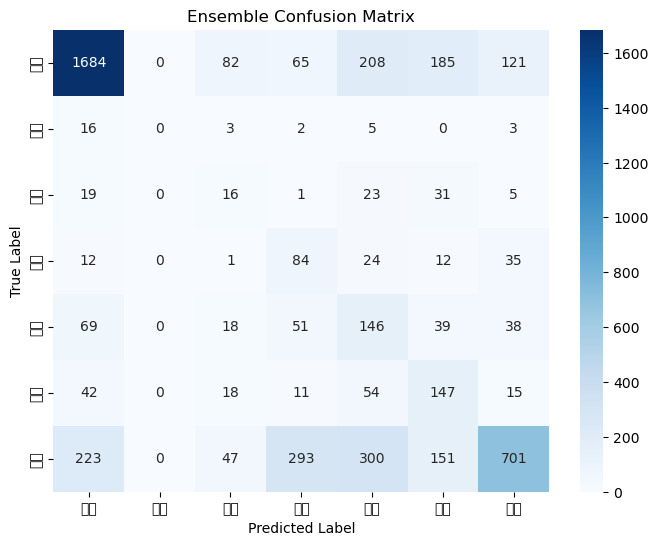

              precision    recall  f1-score   support

          분노       0.82      0.72      0.76      2345
          혐오       0.00      0.00      0.00        29
          공포       0.09      0.17      0.11        95
          기쁨       0.17      0.50      0.25       168
          슬픔       0.19      0.40      0.26       361
          놀람       0.26      0.51      0.35       287
          중립       0.76      0.41      0.53      1715

    accuracy                           0.56      5000
   macro avg       0.33      0.39      0.32      5000
weighted avg       0.68      0.56      0.59      5000



/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ✅ 각 모델 예측값 얻기 (앙상블)
ensemble_predictions = np.zeros((len(X_test), 7))  # 클래스가 7개라 가정

# 모든 모델 예측값 누적
for model in ensemble_models:
    ensemble_predictions += model.predict(X_test)

# ✅ 앙상블 예측값 계산 (Soft Voting: 확률값 평균 후 최종 클래스 선정)
ensemble_predictions /= len(ensemble_models)
y_pred_classes = np.argmax(ensemble_predictions, axis=1)

# ✅ 실제 라벨
y_true = y_test  # 이미 numpy array 형태라면 그대로 사용하면 됨

# ✅ FER2013 기준 class_labels 설정
class_labels = ["분노", "혐오", "공포", "기쁨", "슬픔", "놀람", "중립"]

# ✅ 혼동 행렬 생성
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# ✅ 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Confusion Matrix")
plt.show()

# ✅ 추가 평가 보고서 출력 (Precision, Recall, F1-score 확인)
report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print(report)

Matthews Correlation Coefficient (MCC): 0.4689
Cohen's Kappa Score: 0.4534


/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54800 (\N{HANGUL SYLLABLE HYEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/mambaforge/base/envs/tf_metal/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/mambaforge/bas

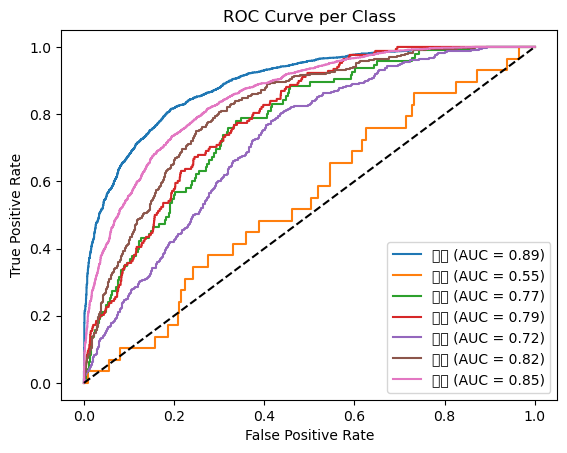

In [28]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 기존에 정의된 변수: y_true, y_pred_classes, ensemble_predictions
class_labels = ["분노", "혐오", "공포", "기쁨", "슬픔", "놀람", "중립"]

# 1️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_true, y_pred_classes)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# 2️⃣ Cohen's Kappa Score
kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"Cohen's Kappa Score: {kappa:.4f}")

# 3️⃣ ROC Curve & AUC (클래스별로 확인)
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4,5,6])

# 클래스별 ROC 및 AUC 계산
for i, label in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], ensemble_predictions[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend(loc='lower right')
plt.show()

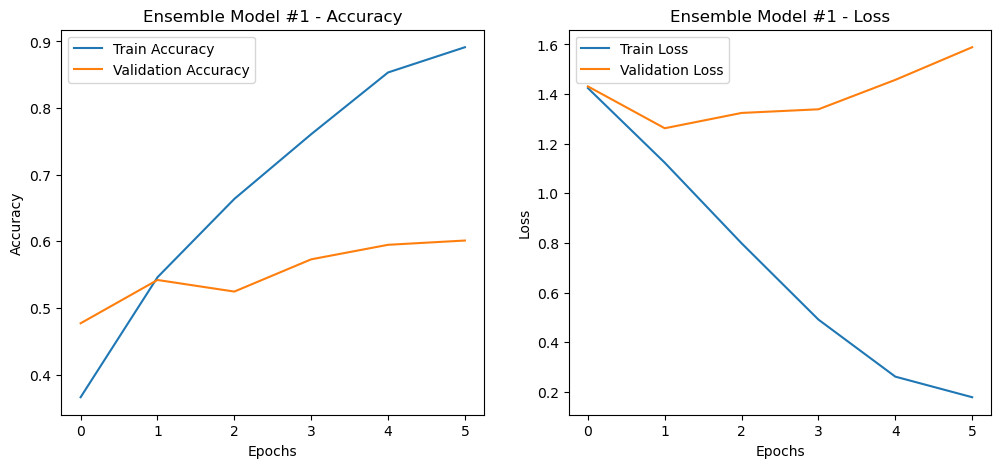

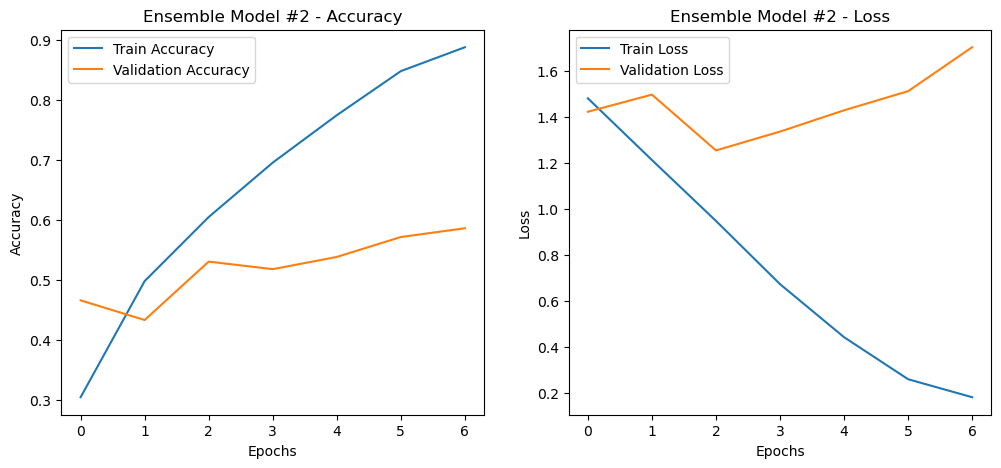

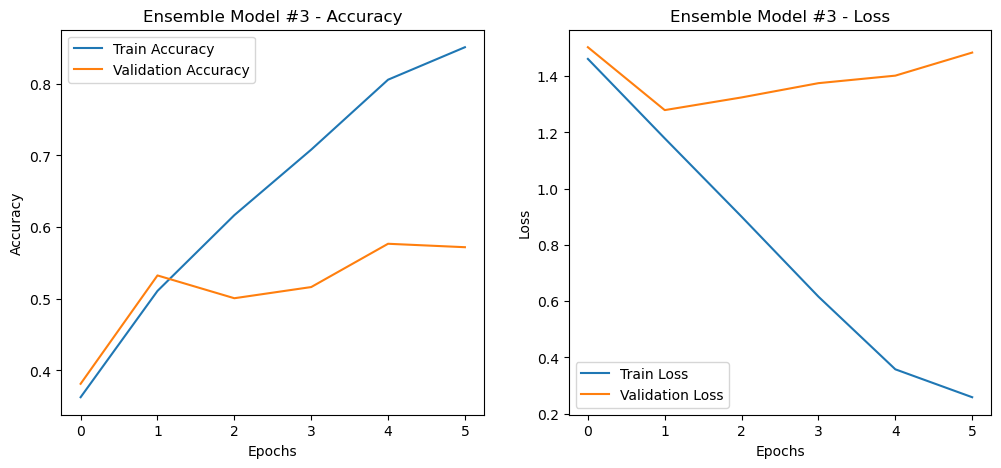

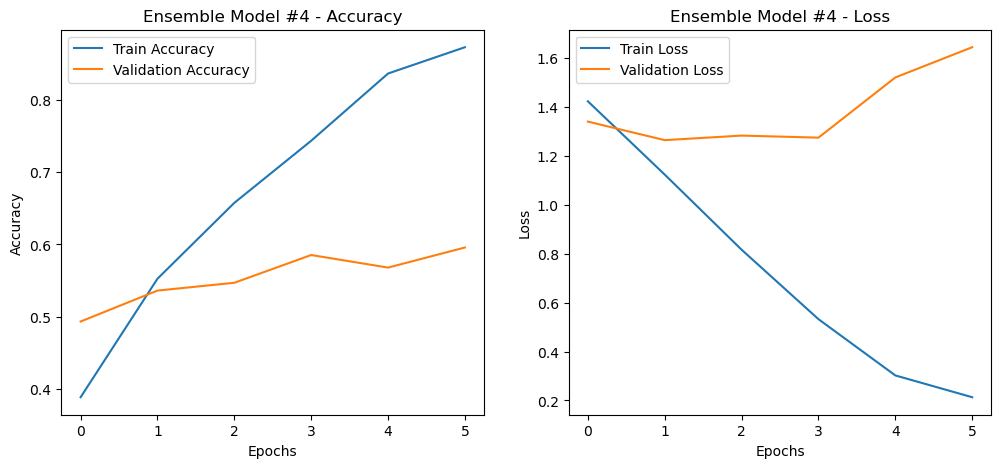

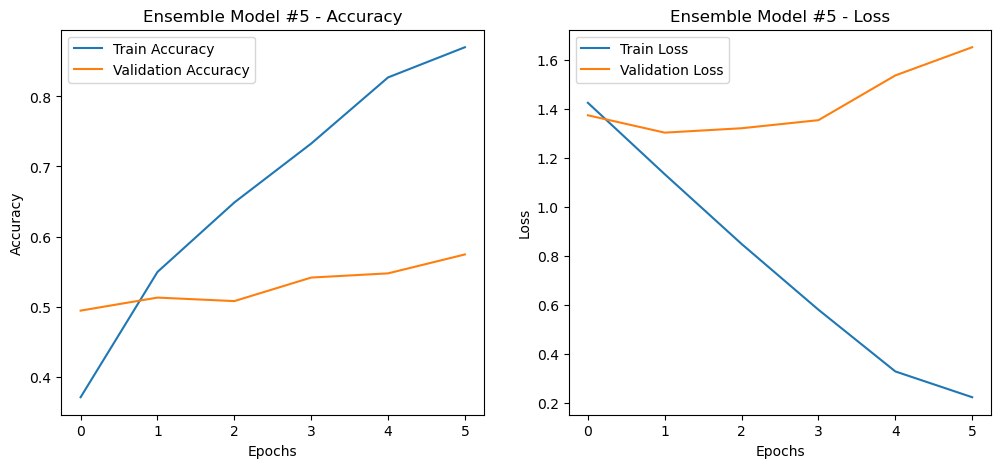

In [94]:
import matplotlib.pyplot as plt

# ✅ 학습 결과 시각화 함수
def plot_training_history(history, title="Model Training History"):
    plt.figure(figsize=(12, 5))

    # 🔹 정확도 그래프
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    # 🔹 손실 그래프
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.show()

# ✅ 모든 앙상블 모델의 학습 결과를 한 번에 시각화
for idx, history in enumerate(histories):
    plot_training_history(history, f"Ensemble Model #{idx+1}")